# Online Testing
The goal of this notebook is to couple the trained ML models to the L96 models and test the parameterizations in an online setting. The trained models are saved in the `models` directory.

In [2]:
%matplotlib inline
import time

import sys
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader

current_dir = os.path.abspath(os.getcwd())
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

from src.l96_model import L96, RK4, L96_eq1_xdot

In [3]:
np.random.seed(14)
torch.manual_seed(14);

In [4]:
linear_weights = torch.load(os.path.join(parent_dir, "models", "linear_model.pth"))
fcnn_weights = torch.load(os.path.join(parent_dir, "models", "fcnn_model.pth"))
nonlocal_fcnn_weights = torch.load(os.path.join(parent_dir, "models", "nonlocal_fcnn_model.pth"))

C:\Users\suman\AppData\Local\Temp\ipykernel_8228\3485951234.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  linear_weights = torch.load(os.path.join(parent_dir, "models"

In [5]:
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(1, 1)  # A single input and a single output

    def forward(self, x):
        # This method is automatically executed when
        # we call a object of this class
        x = self.linear1(x)
        return x


class FCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(1, 16)  # 8 inputs
        self.linear2 = nn.Linear(16, 16)
        self.linear3 = nn.Linear(16, 1)  # 8 outputs

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.linear1(x))
        x = self.relu(self.linear2(x))
        x = self.linear3(x)
        return x


class NonLocal_FCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(8, 16)  # 8 inputs
        self.linear2 = nn.Linear(16, 16)
        self.linear3 = nn.Linear(16, 8)  # 8 outputs

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.linear1(x))
        x = self.relu(self.linear2(x))
        x = self.linear3(x)
        return x

In [6]:
linear_network = LinearRegression()
linear_network.load_state_dict(linear_weights)

local_fcnn_network = FCNN()
local_fcnn_network.load_state_dict(fcnn_weights)

nonlocal_fcnn_network = NonLocal_FCNN()
nonlocal_fcnn_network.load_state_dict(nonlocal_fcnn_weights)

<All keys matched successfully>

In [9]:
T_test = 10
forcing = 18
dt = 0.01

k = 8
j = 32

W = L96(k, j, F = forcing)

X_full, _, _ = W.run(dt, T_test)
X_full = X_full.astype(np.float32)

init_conditions = X_full[0, :]

In [7]:
class GCM_wo_param:
    def __init__(self, F, time_stepping=RK4):
        self.F = F
        self.time_stepping = time_stepping
    def rhs(self, X, _):
        return L96_eq1_xdot(X, self.F)
    def __call__(self, X0, dt, nt, param=[0]):
        time, hist, X = (
            dt * np.arange(nt+1),
            np.zeros((nt+1, len(X0))) * np.nan,
            X0.copy()
        )
        hist[0] = X

        for n in range(nt):
            X = self.time_stepping(self.rhs, dt, X, param)
            hist[n+1], time[n+1] = X, dt * (n+1)
        return hist, time

In [10]:
gcm_no_param = GCM_wo_param(forcing)
X_no_param, t = gcm_no_param(init_conditions, dt, int(T_test/dt))

In [11]:
class GCM_network:
    def __init__(self, F, network, time_stepping=RK4):
        self.F = F
        self.network = network
        self.time_stepping = time_stepping
    def rhs(self, X, _):
        if self.network.linear1.in_features == 1:
            X_torch = torch.from_numpy(X)
            X_torch = torch.unsqueeze(X_torch, 1)  # Add a dimension for batch size
        else:
            X_torch = torch.from_numpy(np.expand_dims(X, 0))
        return L96_eq1_xdot(X, self.F) + np.squeeze(self.network(X_torch).data.numpy())
    def __call__(self, X0, dt, nt, param=[0]):
        time, hist, X = (
            dt * np.arange(nt+1),
            np.zeros((nt+1, len(X0))) * np.nan,
            X0.copy()
        )
        hist[0] = X

        for n in range(nt):
            X = self.time_stepping(self.rhs, dt, X, param)
            hist[n+1], time[n+1] = X, dt * (n+1)
        return hist, time

In [12]:
gcm_linear_net = GCM_network(forcing, linear_network)
Xnn_linear, t = gcm_linear_net(init_conditions, dt, int(T_test/dt), linear_network)

gcm_local_net = GCM_network(forcing, local_fcnn_network)
Xnn_local, t = gcm_local_net(init_conditions, dt, int(T_test/dt), local_fcnn_network)

gcm_nonlocal_net = GCM_network(forcing, nonlocal_fcnn_network)
Xnn_nonlocal, t = gcm_nonlocal_net(init_conditions, dt, int(T_test/dt), nonlocal_fcnn_network)

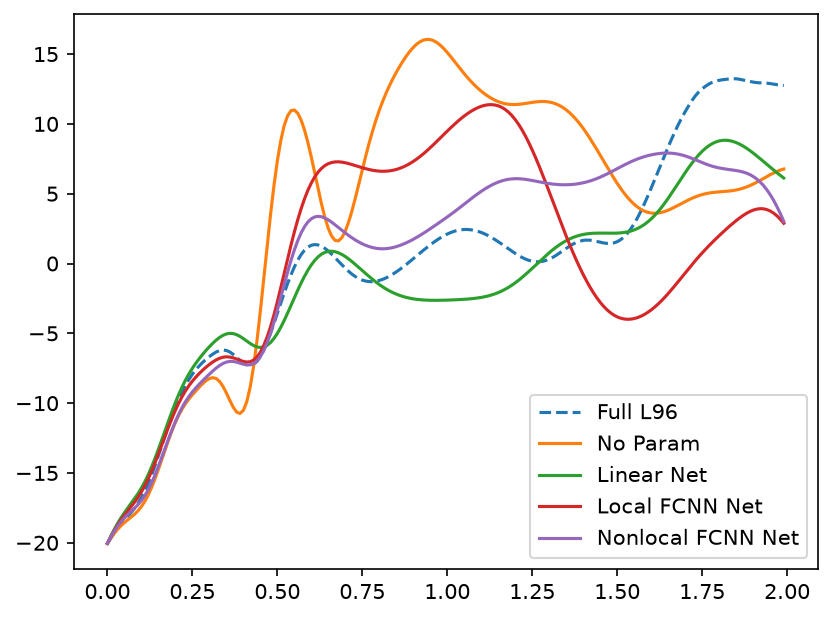

In [14]:
time_i = 200
plt.figure(dpi=150)
plt.plot(t[:time_i], X_full[:time_i, 4], "--",label = "Full L96")
plt.plot(t[:time_i], X_no_param[:time_i, 4], label = "No Param")
plt.plot(t[:time_i], Xnn_linear[:time_i, 4], label = "Linear Net")
plt.plot(t[:time_i], Xnn_local[:time_i, 4], label = "Local FCNN Net")
plt.plot(t[:time_i], Xnn_nonlocal[:time_i, 4], label = "Nonlocal FCNN Net")
plt.legend()

In [15]:
err_linear, err_local, err_nonlocal = [], [], []
T_Test = 1

for i in range(90):
    init_conditions_i = X_full[i*10, :]

    gcm_linear_net = GCM_network(forcing, linear_network)
    Xnn_linear, t = gcm_linear_net(init_conditions_i, dt, int(T_Test/dt), linear_network)

    gcm_local_net = GCM_network(forcing, local_fcnn_network)
    Xnn_local, t = gcm_local_net(init_conditions_i, dt, int(T_Test/dt), local_fcnn_network)

    gcm_nonlocal_net = GCM_network(forcing, nonlocal_fcnn_network)
    Xnn_nonlocal, t = gcm_nonlocal_net(init_conditions_i, dt, int(T_Test/dt), nonlocal_fcnn_network)

    err_linear.append(np.sum(np.abs(X_full[i*10 : i*10 + T_Test * 100 + 1] - Xnn_linear)))
    err_local.append(np.sum(np.abs(X_full[i*10 : i*10 + T_Test * 100 + 1] - Xnn_local)))
    err_nonlocal.append(np.sum(np.abs(X_full[i*10 : i*10 + T_Test * 100 + 1] - Xnn_nonlocal)))

print("Sum of errors for Linear Net:", np.sum(err_linear))
print("Sum of errors for Local FCNN Net:", np.sum(err_local))
print("Sum of errors for Nonlocal FCNN Net:", np.sum(err_nonlocal))

Sum of errors for Linear Net: 53675.95370561752
Sum of errors for Local FCNN Net: 31286.908017966663
Sum of errors for Nonlocal FCNN Net: 39563.75752047234
